In [ ]:
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks
smt = SMOTETomek(random_state= 42)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold, validation_curve, learning_curve, cross_validate
from sklearn.linear_model import LogisticRegression, LinearRegression, Lasso, Ridge, ElasticNet, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler, LabelEncoder
from xgboost import XGBClassifier

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, confusion_matrix, classification_report

import warnings
warnings.simplefilter(action = 'ignore')


In [ ]:
df_encoded = pd.read_csv("/content/df_encoded_churn.csv")

In [ ]:
df_encoded

,Tenure,CityTier,WarehouseToHome,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Digital_Engagement,PreferredLoginDevice_encoded,PreferredPaymentMode_encoded,Gender_encoded,PreferedOrderCat_encoded,MaritalStatus_encoded,Churn
0,-0.733315,1.459845,-1.163171,-0.741926,1.892513,1.589311,-1.298981,-0.402473,-0.697548,0.100055,-0.355608,-0.423270,-0.832468,-0.534394,-1.118745,-0.788593,1.528338,1
1,-0.228490,-0.716416,-0.917571,-0.018534,1.106470,1.589311,-0.192956,-0.929508,-0.697548,-1.335692,-1.148733,0.224605,-0.605495,0.992366,0.672571,1.232355,1.472806,1
2,-0.138127,-0.716416,1.784036,-0.018534,0.713449,1.589311,-0.469462,-0.929508,-0.697548,-0.474244,-1.161332,-0.639229,-0.605495,-0.574364,0.672571,1.232355,1.472806,1
3,-1.215320,1.459845,-0.057969,1.428251,1.499491,-0.629203,2.019094,-0.929508,-0.697548,-0.474244,-0.881107,-0.639229,-0.437132,-0.631335,0.738591,-0.773988,1.491098,1
4,-1.215320,-0.716416,-0.426370,1.428251,-0.465615,-0.629203,-1.298981,-0.402473,-0.697548,-0.474244,-0.971941,-0.941571,-0.437132,-0.631335,0.738591,1.157047,1.491098,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5030,-0.612814,-0.716416,-0.426370,1.428251,-0.858636,-0.629203,1.189575,0.124562,-0.351079,2.110100,0.953670,1.088440,1.147151,-0.574364,0.672571,-0.760904,1.472806,0
5031,-1.094819,1.459845,-0.426370,-0.018534,-0.858636,-0.629203,0.913069,0.124562,-0.351079,-1.048543,-0.462699,-0.207312,-0.766160,1.023856,-1.104854,1.271271,1.437574,0
5032,0.351197,-0.716416,-0.303569,1.428251,0.713449,-0.629203,0.083550,-0.402473,-0.351079,1.133792,0.964846,0.872481,-0.453861,-0.479358,1.221004,-0.037528,-0.732282,0
5033,-1.094819,-0.716416,-0.549170,0.704859,-0.465615,1.589311,1.466082,-0.402473,-0.351079,-0.187095,0.182694,-1.071146,-0.832468,-0.534394,0.572758,-0.788593,-0.812184,0


In [ ]:
X = df_encoded.drop('Churn' , axis = 1)
Y = df_encoded['Churn']

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
import warnings

warnings.filterwarnings("ignore")

**Using SMOTETomek**

In [ ]:
from imblearn.combine import SMOTETomek
smt = SMOTETomek(random_state=42)
x_smt , y_smt = smt.fit_resample(X , Y)

In [ ]:
x_smt.shape, y_smt.shape

((8392, 17), (8392,))

In [ ]:
x_train_smt,  x_test_smt , y_train_smt , y_test_smt = train_test_split(x_smt , y_smt , test_size = 0.30 , random_state = 42)

In [ ]:
logis_clf = LogisticRegression()
svm_clf = SVC()
dt_clf = DecisionTreeClassifier()
rf_clf = RandomForestClassifier()
XGB_clf = XGBClassifier()
ada_clf = AdaBoostClassifier()

In [ ]:
clf_list = [logis_clf, svm_clf, dt_clf, rf_clf, XGB_clf, ada_clf]
clf_name_list = ['Logistic Regression', 'Support Vector Machine', 'Decision Tree', 'Random Forest', 'XGBClassifier' , 'AdaBoostClassifier']

for clf in clf_list:
    clf.fit(x_train_smt,y_train_smt)

In [ ]:
train_acc_list = []
test_acc_list = []

print('Using SMOTETOMEK')
print()

for clf,name in zip(clf_list,clf_name_list):
    y_pred_train = clf.predict(x_train_smt)
    y_pred_test = clf.predict(x_test_smt)
    print(f'Using model: {name}')
    print(f'Trainning Score: {clf.score(x_train_smt, y_train_smt)}')
    print(f'Test Score: {clf.score(x_test_smt, y_test_smt)}')
    print(f'Acc Train: {accuracy_score(y_train_smt, y_pred_train)}')
    print(f'Acc Test: {accuracy_score(y_test_smt, y_pred_test)}')
    train_acc_list.append(accuracy_score(y_train_smt, y_pred_train))
    test_acc_list.append(accuracy_score(y_test_smt, y_pred_test))
    print()
    print()

Using SMOTETOMEK

Using model: Logistic Regression
Trainning Score: 0.8144364998297583
Test Score: 0.8034154090548054
Acc Train: 0.8144364998297583
Acc Test: 0.8034154090548054


Using model: Support Vector Machine
Trainning Score: 0.9542049710589037
Test Score: 0.9328832406671962
Acc Train: 0.9542049710589037
Acc Test: 0.9328832406671962


Using model: Decision Tree
Trainning Score: 1.0
Test Score: 0.9154090548054011
Acc Train: 1.0
Acc Test: 0.9154090548054011


Using model: Random Forest
Trainning Score: 1.0
Test Score: 0.9630659253375695
Acc Train: 1.0
Acc Test: 0.9630659253375695


Using model: XGBClassifier
Trainning Score: 1.0
Test Score: 0.9690230341540905
Acc Train: 1.0
Acc Test: 0.9690230341540905


Using model: AdaBoostClassifier
Trainning Score: 0.8615934627170582
Test Score: 0.8498808578236696
Acc Train: 0.8615934627170582
Acc Test: 0.8498808578236696




In [ ]:

models = pd.DataFrame({'Train_Accuracy': train_acc_list , 'Test_Accuracy' : test_acc_list}  , index = clf_name_list)
models

,Train_Accuracy,Test_Accuracy
Logistic Regression,0.814436,0.803415
Support Vector Machine,0.954205,0.932883
Decision Tree,1.000000,0.915409
Random Forest,1.000000,0.963066
XGBClassifier,1.000000,0.969023
AdaBoostClassifier,0.861593,0.849881


In [ ]:
import plotly.express as px
# Models vs Train Accuracies
fig = px.bar(models, x=models['Train_Accuracy'], y = models.index ,color=models['Train_Accuracy'],title="<b>"+'Models Vs Train Accuracies',text_auto= True , color_continuous_scale='Reds')
fig.update_layout(hovermode='x',title_font_size=30)
fig.update_layout(
title_font_color="black",
template="plotly",
title_font_size=30,
hoverlabel_font_size=20,
title_x=0.5,
xaxis_title='Train Accuracy',
yaxis_title='Models Names',
)
fig.show()


# Models vs Test Accuracies
fig = px.bar(models, x=models['Test_Accuracy'], y = models.index ,color=models['Test_Accuracy'],title="<b>"+'Models Vs Test Accuracies',text_auto= True , color_continuous_scale='Reds')
fig.update_layout(hovermode='x',title_font_size=30)
fig.update_layout(
title_font_color="black",
template="plotly",
title_font_size=30,
hoverlabel_font_size=20,
title_x=0.5,
xaxis_title='Test Accuracy',
yaxis_title='Models Names',
)
fig.show()

# Using SMOTEENN

In [ ]:
from imblearn.combine import SMOTEENN
sme = SMOTEENN(random_state=42)
x_sme , y_sme = sme.fit_resample(X , Y)

In [ ]:
x_sme.shape, y_sme.shape

((7962, 17), (7962,))

In [ ]:
x_train_sme , x_test_sme , y_train_sme , y_test_sme = train_test_split(x_sme , y_sme , test_size = 0.30 , random_state = 42)

In [ ]:
logis_clf_sme = LogisticRegression()
svm_clf_sme = SVC()
dt_clf_sme = DecisionTreeClassifier()
rf_clf_sme = RandomForestClassifier()
XGB_clf_sme = XGBClassifier()
ada_clf_sme = AdaBoostClassifier()

In [ ]:
clf_list = [logis_clf_sme, svm_clf_sme, dt_clf_sme, rf_clf_sme, XGB_clf_sme, ada_clf_sme]
clf_name_list = ['Logistic Regression', 'Support Vector Machine', 'Decision Tree', 'Random Forest', 'XGBClassifier' , 'AdaBoostClassifier']

for clf in clf_list:
    clf.fit(x_train_sme,y_train_sme)

In [ ]:
train_acc_list = []
test_acc_list = []

print('Using SMOTEENN')
print()

for clf,name in zip(clf_list,clf_name_list):
    y_pred_train_sme = clf.predict(x_train_sme)
    y_pred_test_sme = clf.predict(x_test_sme)
    print(f'Using model: {name}')
    print(f'Trainning Score: {clf.score(x_train_sme, y_train_sme)}')
    print(f'Test Score: {clf.score(x_test_sme, y_test_sme)}')
    print(f'Acc Train: {accuracy_score(y_train_sme, y_pred_train_sme)}')
    print(f'Acc Test: {accuracy_score(y_test_sme, y_pred_test_sme)}')
    train_acc_list.append(accuracy_score(y_train_sme, y_pred_train_sme))
    test_acc_list.append(accuracy_score(y_test_sme, y_pred_test_sme))
    print()
    print()

Using SMOTEENN

Using model: Logistic Regression
Trainning Score: 0.8268437107482505
Test Score: 0.8137295939723734
Acc Train: 0.8268437107482505
Acc Test: 0.8137295939723734


Using model: Support Vector Machine
Trainning Score: 0.9711107123631796
Test Score: 0.9518627040602763
Acc Train: 0.9711107123631796
Acc Test: 0.9518627040602763


Using model: Decision Tree
Trainning Score: 1.0
Test Score: 0.9334449560485559
Acc Train: 1.0
Acc Test: 0.9334449560485559


Using model: Random Forest
Trainning Score: 1.0
Test Score: 0.9732105483465885
Acc Train: 1.0
Acc Test: 0.9732105483465885


Using model: XGBClassifier
Trainning Score: 1.0
Test Score: 0.9778149853495186
Acc Train: 1.0
Acc Test: 0.9778149853495186


Using model: AdaBoostClassifier
Trainning Score: 0.8822896106226449
Test Score: 0.8714943491000419
Acc Train: 0.8822896106226449
Acc Test: 0.8714943491000419




In [ ]:
models_sme = pd.DataFrame({'Train_Accuracy': train_acc_list , 'Test_Accuracy' : test_acc_list}  , index = clf_name_list)
models_sme

,Train_Accuracy,Test_Accuracy
Logistic Regression,0.826844,0.813730
Support Vector Machine,0.971111,0.951863
Decision Tree,1.000000,0.933445
Random Forest,1.000000,0.973211
XGBClassifier,1.000000,0.977815
AdaBoostClassifier,0.882290,0.871494


In [ ]:
# ax = sns.histplot(data=models_sme, x=models_sme.index, shrink=.8)

# # Get the current x-axis tick labels.
# labels = [item.get_text() for item in ax.get_xticklabels()]

# # Set the new tick labels with the model names and a 45-degree rotation.
# # The `ha='right'` (horizontal alignment) and `rotation_mode='anchor'`
# # help ensure the labels are correctly positioned and don't overlap.
# plt.xticks(
#     ticks=range(len(labels)),
#     labels=models_sme.index,
#     rotation=45,
#     ha='right'
# )

# # Use plt.tight_layout() to automatically adjust the plot to fit the labels
# plt.tight_layout()

# plt.show()


# #when trying to plot two in one figure

# plt.figure(figsize=(12, 6))

# # Define the width of the bars
# bar_width = 0.35

# # Set the positions for the groups on the x-axis
# index = np.arange(len(df.index))

# # --- 3. Plot the two sets of bars with an offset ---
# # Plot bars for 'f1' shifted slightly to the left
# plt.bar(index - bar_width/2, df['f1'], bar_width, label='f1')

# # Plot bars for 'f2' shifted slightly to the right
# plt.bar(index + bar_width/2, df['f2'], bar_width, label='f2')

# # --- 4. Customize the plot for clarity ---
# # Set the x-axis ticks to be at the center of the groups
# plt.xticks(index, df.index, rotation=45, ha='right')

# # Add labels and a title
# plt.xlabel('Model Names')
# plt.ylabel('Values')
# plt.title('Comparison of f1 and f2 Values per Model')
# plt.legend() # Show the legend to differentiate the bars

# plt.tight_layout() # Adjust layout to prevent labels from being cut off
# plt.show()

In [ ]:
print('Using SMOTEENN')
import plotly.express as px
# Models vs Train Accuracies
fig = px.bar(models_sme, x=models_sme['Train_Accuracy'], y = models_sme.index ,color=models_sme['Train_Accuracy'],title="<b>"+'Models Vs Train Accuracies',text_auto= True , color_continuous_scale='Blues')
fig.update_layout(hovermode='x',title_font_size=30)
fig.update_layout(
title_font_color="black",
template="plotly",
title_font_size=30,
hoverlabel_font_size=20,
title_x=0.5,
xaxis_title='Train Accuracy',
yaxis_title='Models Names',
)
fig.show()


# Models vs Test Accuracies
fig = px.bar(models_sme, x=models_sme['Test_Accuracy'], y = models_sme.index ,color=models_sme['Test_Accuracy'],title="<b>"+'Models Vs Test Accuracies',text_auto= True , color_continuous_scale='Reds')
fig.update_layout(hovermode='x',title_font_size=30)
fig.update_layout(
title_font_color="black",
template="plotly",
title_font_size=30,
hoverlabel_font_size=20,
title_x=0.5,
xaxis_title='Test Accuracy',
yaxis_title='Models Names',
)
fig.show()

Using SMOTEENN


In [ ]:
!pip install mlxtend

In [ ]:
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, RocCurveDisplay

Accuracy = 0.8137295939723734
ROC Area under Curve = 0.8126808925552587
              precision    recall  f1-score   support

           0    0.82812   0.77739   0.80196      1159
           1    0.80169   0.84797   0.82418      1230

    accuracy                        0.81373      2389
   macro avg    0.81491   0.81268   0.81307      2389
weighted avg    0.81452   0.81373   0.81340      2389

**********************************************************************


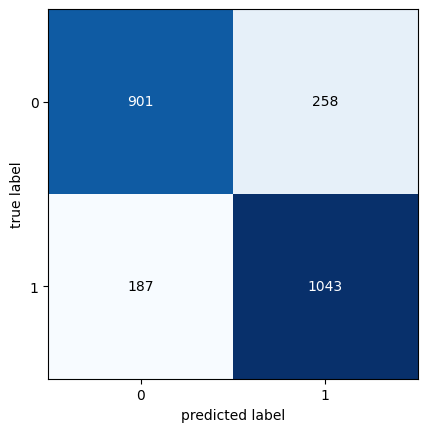

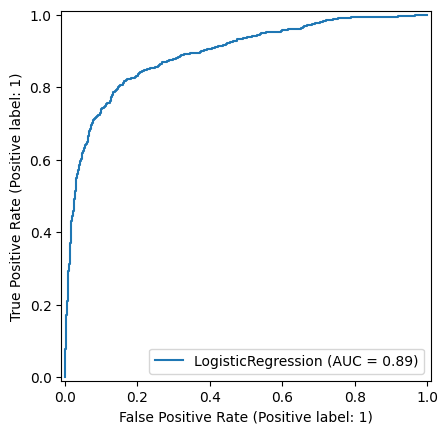

In [ ]:
model= LogisticRegression()
model.fit(x_train_sme,y_train_sme)
y_pred = model.predict(x_test_sme)
accuracy = accuracy_score(y_test_sme, y_pred)
roc_auc1 = roc_auc_score(y_test_sme, y_pred)
print("Accuracy = {}".format(accuracy))
print("ROC Area under Curve = {}".format(roc_auc1))
print(classification_report(y_test_sme,y_pred,digits=5))
plot_confusion_matrix(confusion_matrix(y_test_sme , y_pred))
print('*' * 70)
RocCurveDisplay.from_estimator(model , x_test_scaled , y_test_sme)

Accuracy = 0.9518627040602763
ROC Area under Curve = 0.9509361167813575
              precision    recall  f1-score   support

           0    0.97978   0.91976   0.94882      1159
           1    0.92852   0.98211   0.95456      1230

    accuracy                        0.95186      2389
   macro avg    0.95415   0.95094   0.95169      2389
weighted avg    0.95339   0.95186   0.95178      2389

**********************************************************************


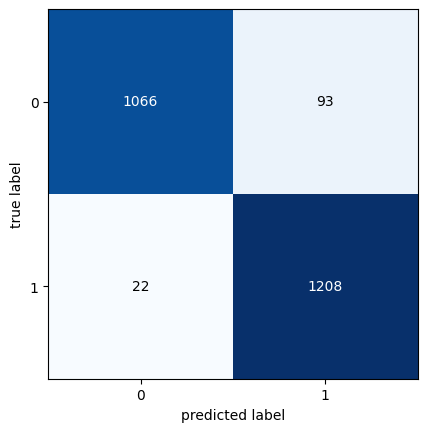

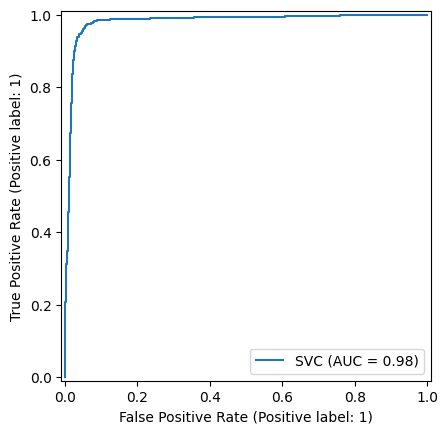

In [ ]:
# Support Vector Machine
model=SVC()
model.fit(x_train_sme,y_train_sme)
y_pred = model.predict(x_test_sme)
accuracy = accuracy_score(y_test_sme, y_pred)
roc_auc1 = roc_auc_score(y_test_sme, y_pred)
print("Accuracy = {}".format(accuracy))
print("ROC Area under Curve = {}".format(roc_auc1))
print(classification_report(y_test_sme,y_pred,digits=5))
plot_confusion_matrix(confusion_matrix(y_test_sme , y_pred))
print('*' * 70)
RocCurveDisplay.from_estimator(model , x_test_scaled , y_test_sme)

Accuracy = 0.9326077856843867
ROC Area under Curve = 0.9323116367488093
              precision    recall  f1-score   support

           0    0.93772   0.92235   0.92997      1159
           1    0.92794   0.94228   0.93505      1230

    accuracy                        0.93261      2389
   macro avg    0.93283   0.93231   0.93251      2389
weighted avg    0.93269   0.93261   0.93259      2389

**********************************************************************


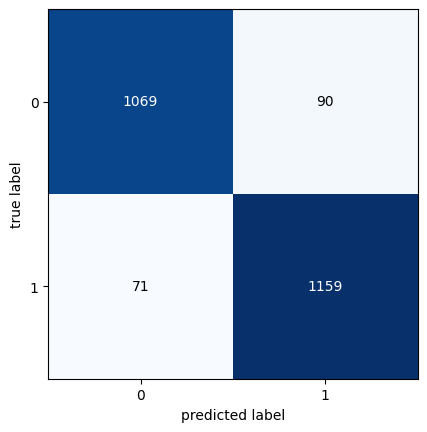

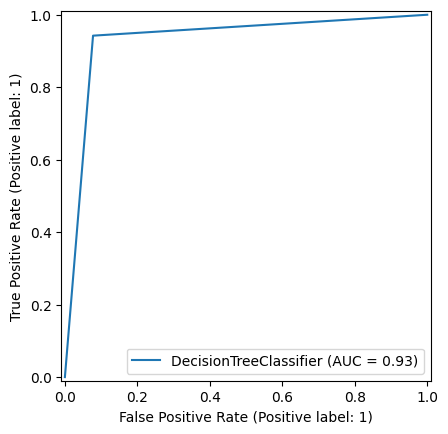

In [ ]:
# Decision Tree
model=DecisionTreeClassifier()
model.fit(x_train_sme,y_train_sme)
y_pred = model.predict(x_test_sme)
accuracy = accuracy_score(y_test_sme, y_pred)
roc_auc1 = roc_auc_score(y_test_sme, y_pred)
print("Accuracy = {}".format(accuracy))
print("ROC Area under Curve = {}".format(roc_auc1))
print(classification_report(y_test_sme,y_pred,digits=5))
plot_confusion_matrix(confusion_matrix(y_test_sme , y_pred))
print('*' * 70)
RocCurveDisplay.from_estimator(model , x_test_scaled , y_test_sme)

Accuracy = 0.9732105483465885
ROC Area under Curve = 0.9729378424068967
              precision    recall  f1-score   support

           0    0.98068   0.96376   0.97215      1159
           1    0.96640   0.98211   0.97419      1230

    accuracy                        0.97321      2389
   macro avg    0.97354   0.97294   0.97317      2389
weighted avg    0.97333   0.97321   0.97320      2389

**********************************************************************


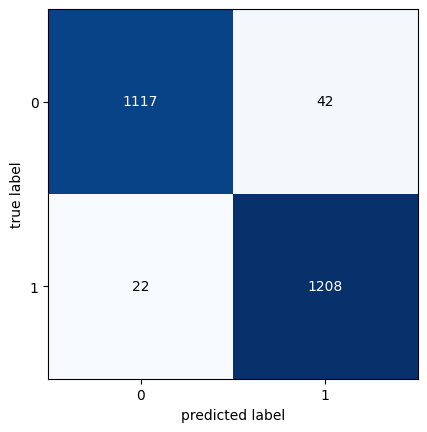

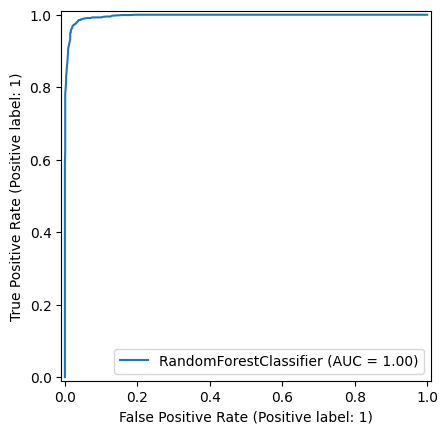

In [ ]:
# random forest
model=RandomForestClassifier()
model.fit(x_train_sme,y_train_sme)
y_pred = model.predict(x_test_sme)
accuracy = accuracy_score(y_test_sme, y_pred)
roc_auc1 = roc_auc_score(y_test_sme, y_pred)
print("Accuracy = {}".format(accuracy))
print("ROC Area under Curve = {}".format(roc_auc1))
print(classification_report(y_test_sme,y_pred,digits=5))
plot_confusion_matrix(confusion_matrix(y_test_sme , y_pred))
print('*' * 70)
RocCurveDisplay.from_estimator(model , x_test_scaled , y_test_sme)


Accuracy = 0.9778149853495186
ROC Area under Curve = 0.9777082149596302
              precision    recall  f1-score   support

           0    0.98003   0.97412   0.97707      1159
           1    0.97575   0.98130   0.97852      1230

    accuracy                        0.97781      2389
   macro avg    0.97789   0.97771   0.97779      2389
weighted avg    0.97783   0.97781   0.97781      2389

**********************************************************************


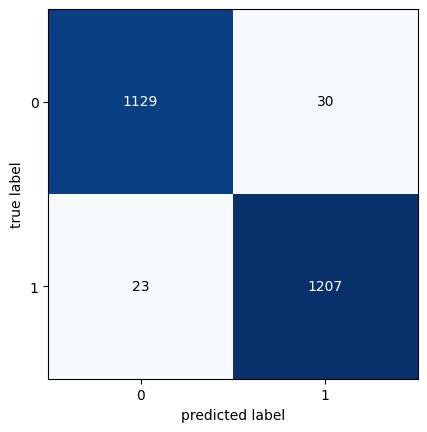

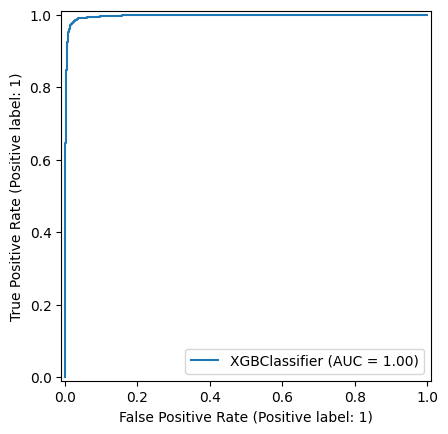

In [ ]:
# XGBoost
model=XGBClassifier()
model.fit(x_train_sme,y_train_sme)
y_pred = model.predict(x_test_sme)
accuracy = accuracy_score(y_test_sme, y_pred)
roc_auc1 = roc_auc_score(y_test_sme, y_pred)
print("Accuracy = {}".format(accuracy))
print("ROC Area under Curve = {}".format(roc_auc1))
print(classification_report(y_test_sme,y_pred,digits=5))
plot_confusion_matrix(confusion_matrix(y_test_sme , y_pred))
print('*' * 70)
RocCurveDisplay.from_estimator(model , x_test_scaled , y_test_sme)

Accuracy = 0.8714943491000419
ROC Area under Curve = 0.8711690762291574
              precision    recall  f1-score   support

           0    0.87303   0.86022   0.86658      1159
           1    0.87009   0.88211   0.87606      1230

    accuracy                        0.87149      2389
   macro avg    0.87156   0.87117   0.87132      2389
weighted avg    0.87152   0.87149   0.87146      2389

**********************************************************************


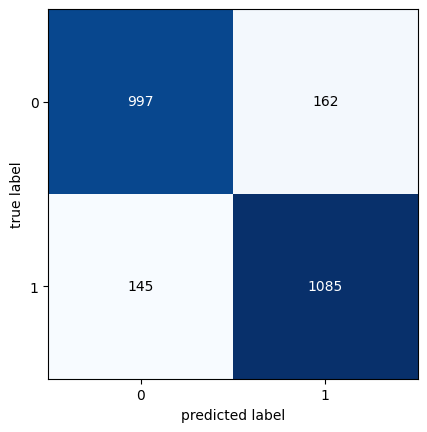

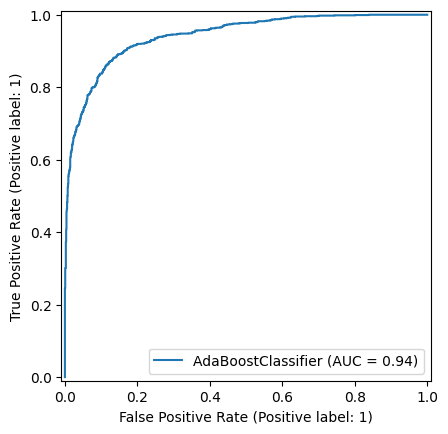

In [ ]:
# adaboost
model=AdaBoostClassifier()
model.fit(x_train_sme,y_train_sme)
y_pred = model.predict(x_test_sme)
accuracy = accuracy_score(y_test_sme, y_pred)
roc_auc1 = roc_auc_score(y_test_sme, y_pred)
print("Accuracy = {}".format(accuracy))
print("ROC Area under Curve = {}".format(roc_auc1))
print(classification_report(y_test_sme,y_pred,digits=5))
plot_confusion_matrix(confusion_matrix(y_test_sme , y_pred))
print('*' * 70)
RocCurveDisplay.from_estimator(model , x_test_scaled , y_test_sme)

In [ ]:
models

,Train_Accuracy,Test_Accuracy
Logistic Regression,0.814436,0.803415
Support Vector Machine,0.954205,0.932883
Decision Tree,1.000000,0.915409
Random Forest,1.000000,0.963066
XGBClassifier,1.000000,0.969023
AdaBoostClassifier,0.861593,0.849881


In [ ]:
models_sme

,Train_Accuracy,Test_Accuracy
Logistic Regression,0.826844,0.813730
Support Vector Machine,0.971111,0.951863
Decision Tree,1.000000,0.933445
Random Forest,1.000000,0.973211
XGBClassifier,1.000000,0.977815
AdaBoostClassifier,0.882290,0.871494


# Going With SMOTEENN

In [ ]:
#x_test_sme, x_train_sme, y_test_sme, y_train_sme

#Hypertuning XGBClassifier params

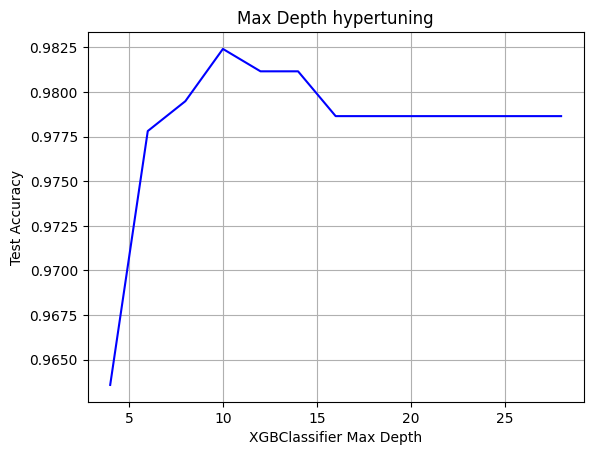

In [ ]:
# Tree max depth hypertuning
max_depth = []
accuracies = []
test_size = 0.3 # Keeping test_size consistent with previous splits

for i in range(4, 30, 2):
    grid = {'max_depth': i}
    clf = XGBClassifier()
    clf.set_params(**grid)

    # Train the model
    clf.fit(x_train_sme, y_train_sme)

    # Evaluate the model on the test set
    accuracy = clf.score(x_test_sme, y_test_sme)

    max_depth.append(i)
    accuracies.append(accuracy)

plt.title("Max Depth hypertuning")
plt.xlabel("XGBClassifier Max Depth")
plt.ylabel("Test Accuracy")
plt.plot(max_depth, accuracies, 'b')
plt.grid()
plt.show()

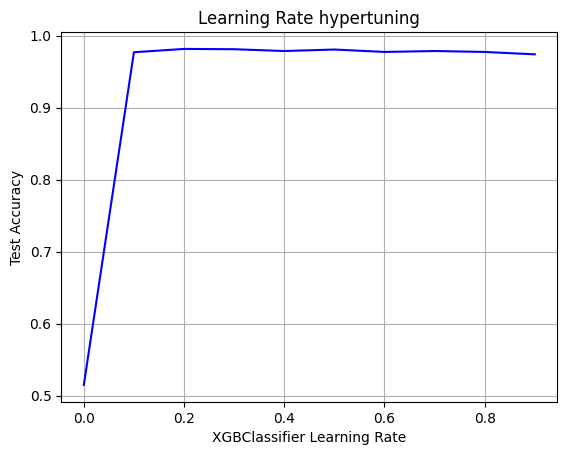

In [ ]:
# Learning rate hypertuning
learning_rates = []
accuracies = []
test_size = 0.7 # This test_size is different from the previous split

for i in range(0, 10, 1):
    eta = i / 10
    grid = {'max_depth': 12, 'eta': eta}
    clf = XGBClassifier()
    clf.set_params(**grid)

    # Train the model
    clf.fit(x_train_sme, y_train_sme)

    # Evaluate the model on the test set
    accuracy = clf.score(x_test_sme, y_test_sme)

    learning_rates.append(eta)
    accuracies.append(accuracy)

plt.title("Learning Rate hypertuning")
plt.xlabel("XGBClassifier Learning Rate")
plt.ylabel("Test Accuracy")
plt.plot(learning_rates, accuracies, 'b')
plt.grid()
plt.show()

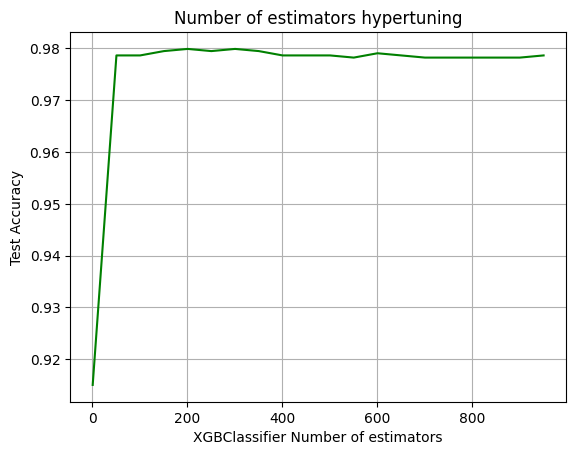

In [ ]:
# Number of estimators hypertuning
n_estimators = []
accuracies = []
test_size = 0.3 # Assuming you want to keep test_size consistent

for i in range(1, 1000, 50):
    grid = {'max_depth': 12, 'eta': 0.4, 'n_estimators': i}
    clf = XGBClassifier()
    clf.set_params(**grid)

    # Train the model
    clf.fit(x_train_sme, y_train_sme)

    # Evaluate the model on the test set
    accuracy = clf.score(x_test_sme, y_test_sme)

    n_estimators.append(i)
    accuracies.append(accuracy)

plt.title("Number of estimators hypertuning")
plt.xlabel("XGBClassifier Number of estimators")
plt.ylabel("Test Accuracy")
plt.plot(n_estimators, accuracies, 'g')
plt.grid()
plt.show()

After hypertuning XGB Classifier params, we use the optimal values:

max_depth: 10

eta: 0.5

n_estimators: 300

Let's do final model with the hypertuned params 🚀

In [ ]:
print("========================== XGBClassifier with hypertuned params ==========================")
grid = {'max_depth': 10, 'eta': 0.5, 'alpha': 0, 'lambda': 1, 'n_estimators': 300}
clf = XGBClassifier()
clf.set_params(**grid)
clf.fit(x_train_sme, y_train_sme)

# Evaluate the model on the test set
accuracy = clf.score(x_test_sme, y_test_sme)
print("Test Accuracy:", accuracy)
print(classification_report(y_test_sme, clf.predict(x_test_sme)))


========================== XGBClassifier with hypertuned params ==========================
Test Accuracy: 0.9782335705316032
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1159
           1       0.97      0.98      0.98      1230

    accuracy                           0.98      2389
   macro avg       0.98      0.98      0.98      2389
weighted avg       0.98      0.98      0.98      2389



**Auto ML**

In [ ]:
!pip install pycaret

In [ ]:
!curl https://pyenv.run | bash
!/root/.pyenv/bin/pyenv install 3.11.0
!/root/.pyenv/versions/3.11.0/bin/pip install pycaret pandas

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   270  100   270    0     0    990      0 --:--:-- --:--:-- --:--:--   989


pyenv: /root/.pyenv/versions/3.11.0 already exists
continue with installation? (y/N) N


In [ ]:
print(f"PyCaret version: pPython.__version__")

PyCaret version: pPython.__version__


In [ ]:
!/root/.pyenv/versions/3.11.0/bin/python -c "from pycaret.classification import setup"

In [ ]:
!/root/.pyenv/versions/3.11.0/bin/python -c "from pycaret.classification import setup; import pandas as pd; df_encoded = pd.read_csv('/content/df_encoded_churn.csv'); setup(df_encoded, target='Churn', train_size=0.7, session_id=42)"

                    Description             Value
0                    Session id                42
1                        Target             Churn
2                   Target type            Binary
3           Original data shape        (5035, 18)
4        Transformed data shape        (5035, 18)
5   Transformed train set shape        (3524, 18)
6    Transformed test set shape        (1511, 18)
7              Numeric features                17
8                    Preprocess              True
9               Imputation type            simple
10           Numeric imputation              mean
11       Categorical imputation              mode
12               Fold Generator   StratifiedKFold
13                  Fold Number                10
14                     CPU Jobs                -1
15                      Use GPU             False
16               Log Experiment             False
17              Experiment Name  clf-default-name
18                          USI              89db


In [ ]:
import sys
# Explicitly run the import statement using the Python 3.11 interpreter
!/root/.pyenv/versions/3.11.0/bin/python -c "import pycaret; print(f'PyCaret version: {pycaret.__version__}')"

print(f"Python version: {sys.version}")


# Now you can import pycaret.classification without issues by using the 3.11 interpreter
!/root/.pyenv/versions/3.11.0/bin/python -c "from pycaret.classification import setup; import pandas as pd; df_encoded = pd.read_csv('/content/df_encoded_churn.csv'); setup(df_encoded, target='Churn', train_size=0.7, session_id=42, verbose=False)"

PyCaret version: 3.3.2
Python version: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]


In [ ]:
print(f"Python version: {sys.version}")

Python version: 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]


In [ ]:
!/root/.pyenv/versions/3.11.0/bin/python -c "from pycaret.classification import setup; import pandas as pd; df = pd.read_csv('/content/df_encoded_churn.csv'); setup(df, target='Churn', train_size=0.7)"

                    Description             Value
0                    Session id              3108
1                        Target             Churn
2                   Target type            Binary
3           Original data shape        (5035, 18)
4        Transformed data shape        (5035, 18)
5   Transformed train set shape        (3524, 18)
6    Transformed test set shape        (1511, 18)
7              Numeric features                17
8                    Preprocess              True
9               Imputation type            simple
10           Numeric imputation              mean
11       Categorical imputation              mode
12               Fold Generator   StratifiedKFold
13                  Fold Number                10
14                     CPU Jobs                -1
15                      Use GPU             False
16               Log Experiment             False
17              Experiment Name  clf-default-name
18                          USI              8385


In [ ]:
!/root/.pyenv/versions/3.11.0/bin/python -c "from pycaret.classification import setup, compare_models; import pandas as pd; df = pd.read_csv('/content/df_encoded_churn.csv'); setup(df, target='Churn', train_size=0.7, verbose=False); best_model = compare_models(); evaluate_model(best_model); print(best_model)"

                                    Model  Accuracy     AUC  Recall   Prec.  \
et                 Extra Trees Classifier    0.9472  0.9827  0.7259  0.9451   
lightgbm  Light Gradient Boosting Machine    0.9410  0.9662  0.7445  0.8852   
rf               Random Forest Classifier    0.9293  0.9659  0.6713  0.8775   
dt               Decision Tree Classifier    0.9098  0.8437  0.7446  0.7238   
gbc          Gradient Boosting Classifier    0.9078  0.9252  0.5910  0.8069   
knn                K Neighbors Classifier    0.9012  0.9361  0.5434  0.8053   
ada                  Ada Boost Classifier    0.8905  0.9035  0.5468  0.7341   
lr                    Logistic Regression    0.8865  0.8722  0.4784  0.7555   
lda          Linear Discriminant Analysis    0.8822  0.8660  0.4495  0.7459   
svm                   SVM - Linear Kernel    0.8717  0.8460  0.3744  0.7286   
ridge                    Ridge Classifier    0.8700  0.8660  0.2588  0.8702   
qda       Quadratic Discriminant Analysis    0.8607 

# Trying Out Neural Networks

In [ ]:
x_train_sme.shape

(5573, 17)

In [ ]:
def ANN(X_train,X_test,y_train,y_test,loss,weights, optimizer):
    model=keras.Sequential([
    keras.layers.Dense(26,activation='relu'),
    keras.layers.Dense(15,activation='relu'),
    keras.layers.Dense(1,activation='sigmoid')
    ])
    model.compile(optimizer=optimizer,loss=loss,metrics=['accuracy'])

    if weights==-1:
        model.fit(X_train,y_train,epochs=100)
    else:
        model.fit(X_train,y_train,epochs=100,class_weight=weights)
    print(model.evaluate(X_test,y_test))
    y_pred=model.predict(X_test)
    y_pred=np.round(y_pred)
    print("Classification_report: ",classification_report(y_test,y_pred))
    return y_pred

In [ ]:
import keras

y_pred=ANN(x_train_sme,x_test_sme,y_train_sme,y_test_sme,'binary_crossentropy',-1, optimizer='adam')

Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6982 - loss: 0.5601
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8282 - loss: 0.3930
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8441 - loss: 0.3713
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8450 - loss: 0.3613
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8546 - loss: 0.3422
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8553 - loss: 0.3339
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8711 - loss: 0.3126
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8638 - loss: 0.3000
Epoch 9/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8794 - loss: 0.2886
Epoch 10/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8790 - loss: 0.2774
Epoch 11/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8906 - loss: 0.2730
Epoch 12/100
175/175 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
def ANN(X_train,X_test,y_train,y_test,loss,weights, optimizer):
    model=keras.Sequential([
    keras.layers.Dense(26,activation='tanh'),
    keras.layers.Dense(15,activation='tanh'),
    keras.layers.Dense(1,activation='sigmoid')
    ])
    model.compile(optimizer=optimizer,loss=loss,metrics=['accuracy'])

    if weights==-1:
        model.fit(X_train,y_train,epochs=100)
    else:
        model.fit(X_train,y_train,epochs=100,class_weight=weights)
    print(model.evaluate(X_test,y_test))
    y_pred=model.predict(X_test)
    y_pred=np.round(y_pred)
    print("Classification_report: ",classification_report(y_test,y_pred))
    return y_pred

In [ ]:
!pip install scikeras

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'scikeras'

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# It's good practice to set a seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


# --- 1. Define the model-building function for KerasClassifier ---
# This function defines the architecture and must not have any training logic (like .fit or .compile).
# The parameters it takes (like units_layer1) will be set by GridSearchCV.
def create_model(units_layer1=26, units_layer2=15, optimizer='adam', loss='binary_crossentropy'):
    """
    Builds and returns a Keras Sequential model.

    Args:
        units_layer1 (int): Number of units for the first dense layer.
        units_layer2 (int): Number of units for the second dense layer.
        optimizer (str): Name of the optimizer to use.
        loss (str): Name of the loss function to use.
    """
    # Determine the input shape from the training data
    input_shape = (x_train_sme.shape[1],)

    model = keras.Sequential([
        keras.layers.Dense(units_layer1, activation='tanh', input_shape=input_shape),
        keras.layers.Dense(units_layer2, activation='tanh'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    # The .compile() step is necessary inside this function
    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

    return model

# Define class weights
weights = {0:1,1:1}

# --- 2. Wrap the Keras model in a KerasClassifier ---
# This wrapper makes the Keras model compatible with scikit-learn's GridSearchCV.
# We pass the model-building function to the `build_fn` argument.
model = KerasClassifier(
    build_fn=create_model,
    epochs=100,
    batch_size=32,
    verbose=0, # Set to 1 to see training progress for each model in the grid search
    class_weight=weights # Pass class weights directly to the wrapper
)

# --- 3. Define the grid of hyperparameters to search ---
# 'model__' prefix is required for parameters that get passed to the model-building function.
param_grid = {
    'model__optimizer': ['adam', 'rmsprop', 'nadam', 'adamw'],
    'model__loss': ['binary_crossentropy'],
    'model__units_layer1': [32, 64],
    'model__units_layer2': [16, 8]
}

# --- 4. Create and run the GridSearchCV object ---
print("Starting grid search...")
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring='accuracy',
    cv=3,
    n_jobs=-1 # Use all available CPU cores for faster search
)

# Fit the grid search to the data
grid_search_result = grid_search.fit(x_train_sme, y_train_sme)

# --- 5. Print the results ---
print("\nGrid search complete!")
print(f"Best Score: {grid_search_result.best_score_:.4f}")
print("Best Parameters: ", grid_search_result.best_params_)

# --- 6. Evaluate the best model on the test data ---
best_model = grid_search_result.best_estimator_
y_pred_proba = best_model.predict(x_test_sme)
y_pred = np.round(y_pred_proba)

print("\n--- Evaluation of the Best Model ---")
print(f"Test Accuracy: {best_model.score(x_test_sme, y_test_sme):.4f}")
print("Classification Report:")
print(classification_report(y_test_sme, y_pred))

ModuleNotFoundError: No module named 'scikeras'

In [ ]:
import sklearn
print(sklearn.__version__)

In [ ]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.3.1

In [2]:
def build_best_model():
    """
    Builds and compiles the Keras model with the best hyperparameters from the grid search.
    Best Parameters: {'model__loss': 'binary_crossentropy', 'model__optimizer': 'nadam', 'model__units_layer1': 64, 'model__units_layer2': 8}
    """
    # Determine the input shape from the training data
    input_shape = (x_train_sme.shape[1],)

    model = keras.Sequential([
        keras.layers.Dense(64, activation='tanh', input_shape=input_shape),
        keras.layers.Dense(8, activation='tanh'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    # The .compile() step is necessary inside this function
    model.compile(optimizer='nadam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [3]:
# Build the model with the best parameters
best_model = build_best_model()

NameError: name 'x_train_sme' is not defined

In [4]:
# Fit the model to the scaled training data
print("Training the best model...")
best_model.fit(x_train_sme, y_train_sme, epochs=100, batch_size=32, verbose=0)
print("Model training complete.")

Training the best model...


NameError: name 'best_model' is not defined

In [ ]:
# --- 3. Prepare a Prediction Function for LIME ---
# LIME requires a function that takes a numpy array of data and returns a numpy array
# of prediction probabilities for each class (e.g., [[prob_class_0, prob_class_1]]).
def predict_proba_for_lime(data):
    """
    A wrapper function to make predictions compatible with LIME.
    It returns probabilities for both classes (0 and 1) for a binary classification model.
    """
    preds = best_model.predict(data)
    # Stack the probabilities for class 0 (1-preds) and class 1 (preds).
    return np.hstack([1 - preds, preds])

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=335ed5ca1b2554481db4bb1f82b9279219e52c27620c75e3dad2aae21ca85b7d
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import lime
import lime.lime_tabular

In [ ]:
# --- 4. Create the LIME Explainer ---
# The explainer needs to know about your training data and feature/class names.
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=x_train_sme.values,
    feature_names=x_train_sme.columns.tolist(),
    class_names=['Class 0', 'Class 1'],
    mode='classification'
)

In [ ]:
# --- 5. Explain a Single Prediction ---
# Let's pick a random instance from the test set to explain.
instance_to_explain_idx = np.random.randint(0, len(x_test_sme))
instance_to_explain = x_test_sme.iloc[instance_to_explain_idx].values # Get values as numpy array for LIME
true_label = y_test_sme.iloc[instance_to_explain_idx] # Get true label

print(f"\n--- Explaining a Prediction for Test Instance {instance_to_explain_idx} ---")
print(f"True Class: {true_label}")
print(f"Predicted Class: {np.argmax(predict_proba_for_lime(np.expand_dims(instance_to_explain, axis=0)))}")

# Generate the explanation. The `num_features` argument specifies how many of the
# most important features you want to see.
explanation = explainer.explain_instance(
    data_row=instance_to_explain,
    predict_fn=predict_proba_for_lime,
    num_features=5
)


--- Explaining a Prediction for Test Instance 62 ---
True Class: 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predicted Class: 0
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [ ]:
# --- 6. Print the Explanation ---
print("\nLocal explanation (features contributing to the prediction):")
print("-" * 50)
# `explanation.as_list()` returns a list of (feature_name, weight) tuples.
for feature, weight in explanation.as_list():
    # The weight indicates how much the feature contributed to the prediction.
    # A positive weight pushes the prediction towards 'Class 1', a negative weight towards 'Class 0'.
    print(f"  {feature:<20} | Contribution: {weight:+.4f}")


Local explanation (features contributing to the prediction):
--------------------------------------------------
  Tenure > 0.23        | Contribution: -0.3716
  Complain <= -0.63    | Contribution: -0.1710
  PreferedOrderCat_encoded <= -0.77 | Contribution: -0.1630
  CityTier <= -0.72    | Contribution: -0.0879
  Digital_Engagement > 0.87 | Contribution: +0.0872
